In [214]:
import numpy as np
import pandas as pd

In [215]:
dataset = pd.read_csv("C:/Users/USER/Desktop/play_golf.csv")

In [216]:
dataset.head()

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY,PLAY GOLF
0,Rainy,Hot,High,False,No
1,Rainy,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Sunny,Mild,High,False,Yes
4,Sunny,Cool,Normal,False,Yes


In [217]:
from sklearn.preprocessing import OrdinalEncoder

In [218]:
ore = OrdinalEncoder(categories=[["Rainy","Overcast","Sunny"]])

In [219]:
ore.fit(dataset[["OUTLOOK"]])

OrdinalEncoder(categories=[['Rainy', 'Overcast', 'Sunny']])

In [220]:
dataset["OUTLOOK"] = ore.transform(dataset[["OUTLOOK"]])

In [221]:
dataset

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY,PLAY GOLF
0,0.0,Hot,High,False,No
1,0.0,Hot,High,True,No
2,1.0,Hot,High,False,Yes
3,2.0,Mild,High,False,Yes
4,2.0,Cool,Normal,False,Yes
5,2.0,Cool,Normal,True,No
6,1.0,Cool,Normal,True,Yes
7,0.0,Mild,High,False,No
8,0.0,Cool,Normal,False,Yes
9,2.0,Mild,Normal,False,Yes


In [222]:
ore = OrdinalEncoder(categories=[["Cool","Mild","Hot"]])

In [223]:
dataset["TEMPERATURE"] = ore.fit_transform(dataset[["TEMPERATURE"]])

In [224]:
dataset

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY,PLAY GOLF
0,0.0,2.0,High,False,No
1,0.0,2.0,High,True,No
2,1.0,2.0,High,False,Yes
3,2.0,1.0,High,False,Yes
4,2.0,0.0,Normal,False,Yes
5,2.0,0.0,Normal,True,No
6,1.0,0.0,Normal,True,Yes
7,0.0,1.0,High,False,No
8,0.0,0.0,Normal,False,Yes
9,2.0,1.0,Normal,False,Yes


In [225]:
ore = OrdinalEncoder(categories=[["Normal","High"]])

In [226]:
dataset["HUMIDITY"] = ore.fit_transform(dataset[["HUMIDITY"]])

In [227]:
dataset

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY,PLAY GOLF
0,0.0,2.0,1.0,False,No
1,0.0,2.0,1.0,True,No
2,1.0,2.0,1.0,False,Yes
3,2.0,1.0,1.0,False,Yes
4,2.0,0.0,0.0,False,Yes
5,2.0,0.0,0.0,True,No
6,1.0,0.0,0.0,True,Yes
7,0.0,1.0,1.0,False,No
8,0.0,0.0,0.0,False,Yes
9,2.0,1.0,0.0,False,Yes


In [228]:
from sklearn.preprocessing import LabelEncoder

In [229]:
le = LabelEncoder()

In [230]:
dataset["PLAY GOLF"]= le.fit_transform(dataset["PLAY GOLF"])

In [231]:
dataset

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY,PLAY GOLF
0,0.0,2.0,1.0,False,0
1,0.0,2.0,1.0,True,0
2,1.0,2.0,1.0,False,1
3,2.0,1.0,1.0,False,1
4,2.0,0.0,0.0,False,1
5,2.0,0.0,0.0,True,0
6,1.0,0.0,0.0,True,1
7,0.0,1.0,1.0,False,0
8,0.0,0.0,0.0,False,1
9,2.0,1.0,0.0,False,1


In [232]:
x = dataset.iloc[:,0:-1]
y = dataset.iloc[:,-1]

In [233]:
from sklearn.model_selection import train_test_split

In [234]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8)

In [235]:
from sklearn.tree import DecisionTreeClassifier

In [236]:
dt = DecisionTreeClassifier(criterion="entropy")

In [237]:
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [238]:
from sklearn import tree
import matplotlib.pyplot as plt

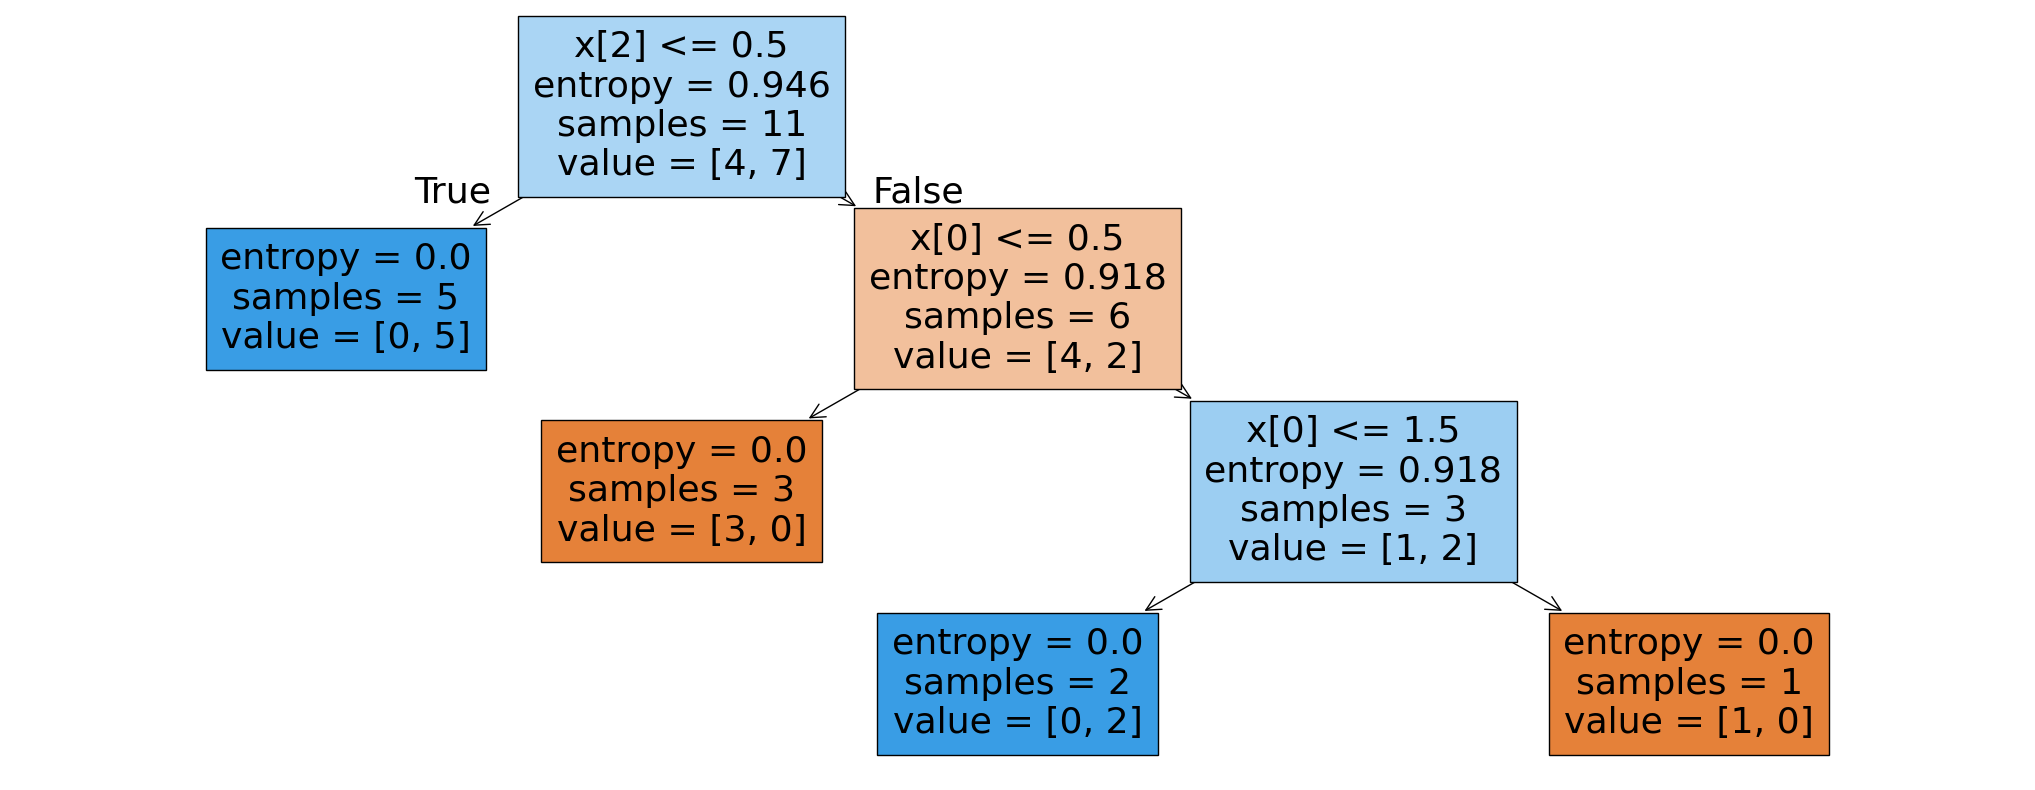

In [239]:
plt.figure(figsize=(26, 10))
tree.plot_tree(dt,filled=True);

In [240]:
x_test

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY
5,2.0,0.0,0.0,True
6,1.0,0.0,0.0,True
3,2.0,1.0,1.0,False


In [241]:
yPred = dt.predict(x_test)

In [242]:
y_test

5    0
6    1
3    1
Name: PLAY GOLF, dtype: int64

In [243]:
from sklearn.metrics import accuracy_score

In [244]:
accuracy_score(yPred,y_test)*100

33.33333333333333

In [245]:
from sklearn.metrics import classification_report

In [246]:
print(classification_report(yPred,y_test))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [247]:
from sklearn.naive_bayes import GaussianNB

In [248]:
gnb = GaussianNB()

In [249]:
gnb.fit(x_train,y_train)

GaussianNB()

In [250]:
yPred = gnb.predict(x_test)

In [251]:
accuracy_score(yPred,y_test)*100

33.33333333333333